# 📱 EDA: Social Media & Mental Health Balance
## Práctica Extra - UT1: Análisis Exploratorio de Datos con Visualizaciones
### Milagros Cancela | Universidad Católica del Uruguay

---

## 🎯 Objetivos del Análisis
- Cargar y explorar dataset real de redes sociales y salud mental
- Crear visualizaciones efectivas con **matplotlib** y **seaborn**
- Identificar patrones entre uso de redes sociales y bienestar mental
- Interpretar relaciones y correlaciones en los datos
- Generar insights accionables para políticas de uso saludable

---

## 📋 Pre-requisitos
- Conceptos básicos de **Python** y **pandas**
- Familiaridad con visualizaciones (matplotlib/seaborn)
- Comprensión de estadística descriptiva básica

---

## 📋 Contexto de Negocio (CRISP-DM: Business Understanding)

### 🔗 Referencias oficiales:
- [Dataset - Social Media and Mental Health Balance](https://www.kaggle.com/datasets/ayeshaimran123/social-media-and-mental-health-balance)
- [Documentación pandas](https://pandas.pydata.org/docs/)
- [Documentación seaborn](https://seaborn.pydata.org/)
- [Documentación matplotlib](https://matplotlib.org/stable/index.html)

### 🧠 Caso de estudio
- **Problema**: El uso excesivo de redes sociales está asociado con problemas de salud mental, especialmente en jóvenes.
- **Objetivo**: Analizar patrones de uso de redes sociales y su relación con indicadores de bienestar mental.
- **Variables clave**: Tiempo de uso diario, plataformas preferidas, nivel de ansiedad/depresión, calidad del sueño, productividad.
- **Valor esperado**: Identificar umbrales de uso saludable y factores de riesgo para diseñar intervenciones.

---

## 📦 1. Setup: Importación de Librerías

In [4]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Verificar versiones
print("✅ Librerías importadas correctamente")
print(f"   • Pandas: {pd.__version__}")
print(f"   • NumPy: {np.__version__}")
print(f"   • Matplotlib: {plt.matplotlib.__version__}")
print(f"   • Seaborn: {sns.__version__}")

✅ Librerías importadas correctamente
   • Pandas: 2.3.3
   • NumPy: 1.26.4
   • Matplotlib: 3.10.1
   • Seaborn: 0.13.2


## 🔽 2. Descarga y Carga del Dataset

### Opción A: Descarga desde Kaggle (Recomendada)

In [5]:
!pip install kagglehub

In [6]:
# Descarga automática desde Kaggle usando kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshaimran123/social-media-and-mental-health-balance")

print("📂 Path to dataset files:", path)

100%|██████████| 5.80k/5.80k [00:00<00:00, 138kB/s]

Extracting files...
📂 Path to dataset files: /Users/milagroscancela/.cache/kagglehub/datasets/ayeshaimran123/social-media-and-mental-health-balance/versions/1


In [7]:
# Cargar el dataset
import os

# Buscar archivo CSV en el path descargado
csv_file = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    df = pd.read_csv(csv_file)
    print(f"✅ Dataset cargado exitosamente desde: {csv_file}")
else:
    print("❌ No se encontró archivo CSV en el path")

✅ Dataset cargado exitosamente desde: /Users/milagroscancela/.cache/kagglehub/datasets/ayeshaimran123/social-media-and-mental-health-balance/versions/1/Mental_Health_and_Social_Media_Balance_Dataset.csv


### Opción B: Carga Manual (Si ya tienes el CSV descargado)

In [8]:
# Si ya descargaste el dataset manualmente, usa esta opción
# df = pd.read_csv('path/to/your/social_media_mental_health.csv')
# print("✅ Dataset cargado desde archivo local")

## 🔍 3. Primera Inspección del Dataset

In [9]:
print("="*70)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("="*70)
print(f"\n✅ Shape del dataset: {df.shape}")
print(f"   • Filas (registros): {df.shape[0]:,}")
print(f"   • Columnas (variables): {df.shape[1]}")
print(f"   • Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 INFORMACIÓN GENERAL DEL DATASET

✅ Shape del dataset: (500, 10)
   • Filas (registros): 500
   • Columnas (variables): 10
   • Memoria utilizada: 0.11 MB


In [10]:
print("\n" + "="*70)
print("PRIMERAS 10 FILAS DEL DATASET")
print("="*70)
display(df.head(10))


PRIMERAS 10 FILAS DEL DATASET


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
5,U006,38,Male,6.6,5.0,7.0,4.0,3.0,LinkedIn,8.0
6,U007,26,Female,7.8,4.0,8.0,2.0,0.0,TikTok,7.0
7,U008,26,Female,7.4,5.0,6.0,1.0,4.0,Instagram,7.0
8,U009,39,Male,4.7,7.0,7.0,6.0,1.0,YouTube,9.0
9,U010,39,Female,6.6,6.0,8.0,0.0,2.0,Facebook,7.0


In [11]:
print("\n" + "="*70)
print("INFORMACIÓN DE COLUMNAS Y TIPOS DE DATOS")
print("="*70)
df.info()


INFORMACIÓN DE COLUMNAS Y TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [12]:
print("\n" + "="*70)
print("ESTADÍSTICOS DESCRIPTIVOS - VARIABLES NUMÉRICAS")
print("="*70)
display(df.describe().T)


ESTADÍSTICOS DESCRIPTIVOS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Age,500.0,32.988,9.960637,16.0,24.0,34.0,41.0,49.0
Daily_Screen_Time(hrs),500.0,5.530,1.734877,1.0,4.3,5.6,6.7,10.8
Sleep_Quality(1-10),500.0,6.304,1.529792,2.0,5.0,6.0,7.0,10.0
Stress_Level(1-10),500.0,6.618,1.542996,2.0,6.0,7.0,8.0,10.0
Days_Without_Social_Media,500.0,3.134,1.858751,0.0,2.0,3.0,5.0,9.0
Exercise_Frequency(week),500.0,2.448,1.428067,0.0,1.0,2.0,3.0,7.0
Happiness_Index(1-10),500.0,8.376,1.524228,4.0,7.0,9.0,10.0,10.0


In [13]:
print("\n" + "="*70)
print("ESTADÍSTICOS DESCRIPTIVOS - VARIABLES CATEGÓRICAS")
print("="*70)
display(df.describe(include='object').T)


ESTADÍSTICOS DESCRIPTIVOS - VARIABLES CATEGÓRICAS


,count,unique,top,freq
User_ID,500,500,U001,1
Gender,500,3,Male,248
Social_Media_Platform,500,6,TikTok,95


## 🧹 4. Análisis de Calidad de Datos

In [14]:
print("\n" + "="*70)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*70)

# Crear DataFrame con resumen de missing values
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo_Dato': df.dtypes
})

missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
)

if missing_data.empty:
    print("\n✅ ¡EXCELENTE! NO SE DETECTARON VALORES FALTANTES")
else:
    print(f"\n⚠️  Se detectaron {missing_data.shape[0]} columnas con valores faltantes:")
    display(missing_data)

# Duplicados
duplicados = df.duplicated().sum()
print(f"\n📋 Registros duplicados: {duplicados:,} ({duplicados/len(df)*100:.2f}%)")


ANÁLISIS DE VALORES FALTANTES

✅ ¡EXCELENTE! NO SE DETECTARON VALORES FALTANTES

📋 Registros duplicados: 0 (0.00%)


In [15]:
# Visualización de valores faltantes (si existen)
if not missing_data.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=missing_data, x='Columna', y='Porcentaje', palette='Reds_r')
    plt.title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('% Faltante')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay valores faltantes para visualizar")

✅ No hay valores faltantes para visualizar


## 📊 5. Análisis Univariado: Explorando Variables Clave

### 5.1. Distribución de Edad

📊 Distribución de Age:
   • Media: 33.0
   • Mediana: 34.0
   • Rango: 16 - 49


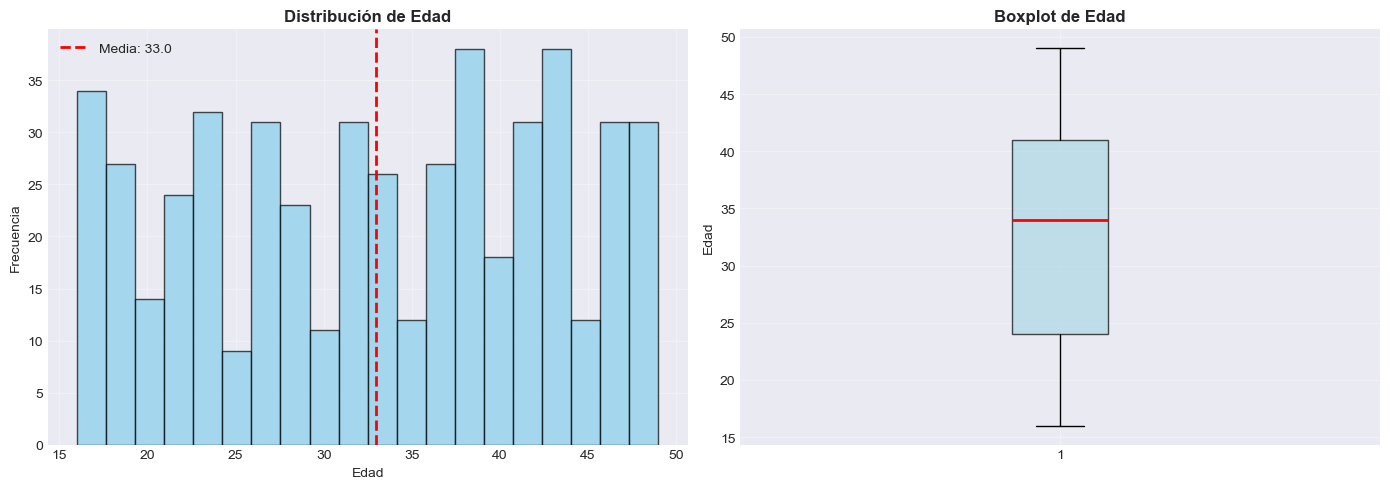

In [16]:
# Análisis de edad (buscar columna que pueda contener edad)
age_cols = [col for col in df.columns if 'age' in col.lower()]

if age_cols:
    age_col = age_cols[0]
    print(f"📊 Distribución de {age_col}:")
    print(f"   • Media: {df[age_col].mean():.1f}")
    print(f"   • Mediana: {df[age_col].median():.1f}")
    print(f"   • Rango: {df[age_col].min():.0f} - {df[age_col].max():.0f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(df[age_col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(df[age_col].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Media: {df[age_col].mean():.1f}')
    axes[0].set_xlabel('Edad')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Edad', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(df[age_col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
    axes[1].set_ylabel('Edad')
    axes[1].set_title('Boxplot de Edad', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No se encontró columna de edad en el dataset")

### 5.2. Tiempo de Uso de Redes Sociales

⏱️ Análisis de Daily_Screen_Time(hrs):
   • Media: 5.53 horas/día
   • Mediana: 5.60 horas/día
   • Desv. Estándar: 1.73
   • Rango: 1.0 - 10.8 horas


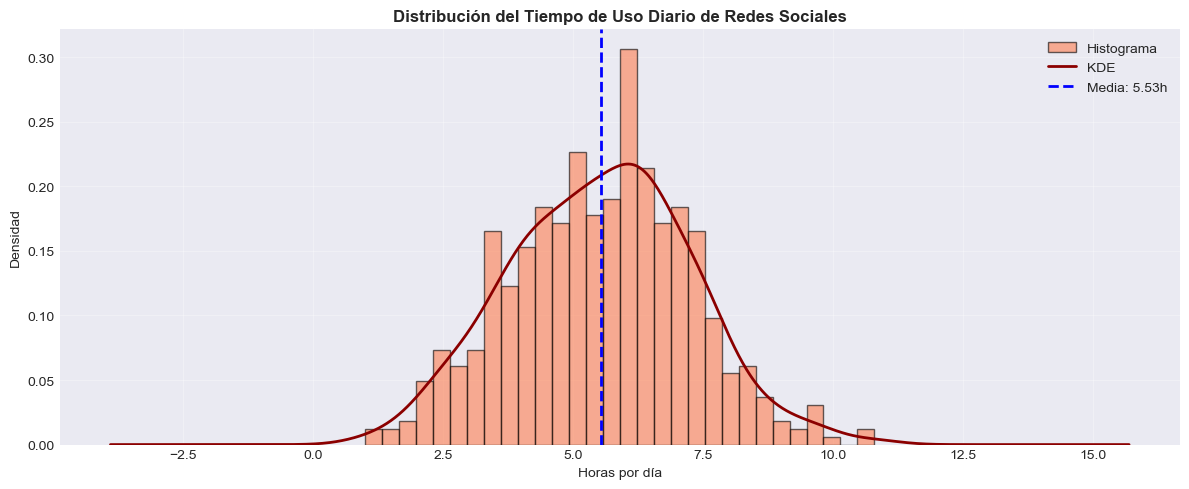

In [17]:
# Buscar columnas relacionadas con tiempo de uso
time_cols = [col for col in df.columns if any(word in col.lower() 
             for word in ['time', 'hours', 'usage', 'spent', 'daily'])]

if time_cols:
    time_col = time_cols[0]
    print(f"⏱️ Análisis de {time_col}:")
    print(f"   • Media: {df[time_col].mean():.2f} horas/día")
    print(f"   • Mediana: {df[time_col].median():.2f} horas/día")
    print(f"   • Desv. Estándar: {df[time_col].std():.2f}")
    print(f"   • Rango: {df[time_col].min():.1f} - {df[time_col].max():.1f} horas")
    
    plt.figure(figsize=(12, 5))
    
    # Histograma con KDE
    plt.hist(df[time_col].dropna(), bins=30, color='coral', 
            alpha=0.6, edgecolor='black', density=True, label='Histograma')
    df[time_col].dropna().plot(kind='kde', color='darkred', 
                              linewidth=2, label='KDE')
    plt.axvline(df[time_col].mean(), color='blue', linestyle='--', 
               linewidth=2, label=f'Media: {df[time_col].mean():.2f}h')
    plt.xlabel('Horas por día')
    plt.ylabel('Densidad')
    plt.title('Distribución del Tiempo de Uso Diario de Redes Sociales', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No se encontró columna de tiempo de uso")

### 5.3. Plataformas de Redes Sociales Más Usadas

📱 Análisis de Days_Without_Social_Media:

   • Plataformas únicas: 9

Top 5 plataformas:
   1. 3.0: 92 usuarios (18.4%)
   2. 4.0: 87 usuarios (17.4%)
   3. 2.0: 86 usuarios (17.2%)
   4. 5.0: 78 usuarios (15.6%)
   5. 1.0: 58 usuarios (11.6%)


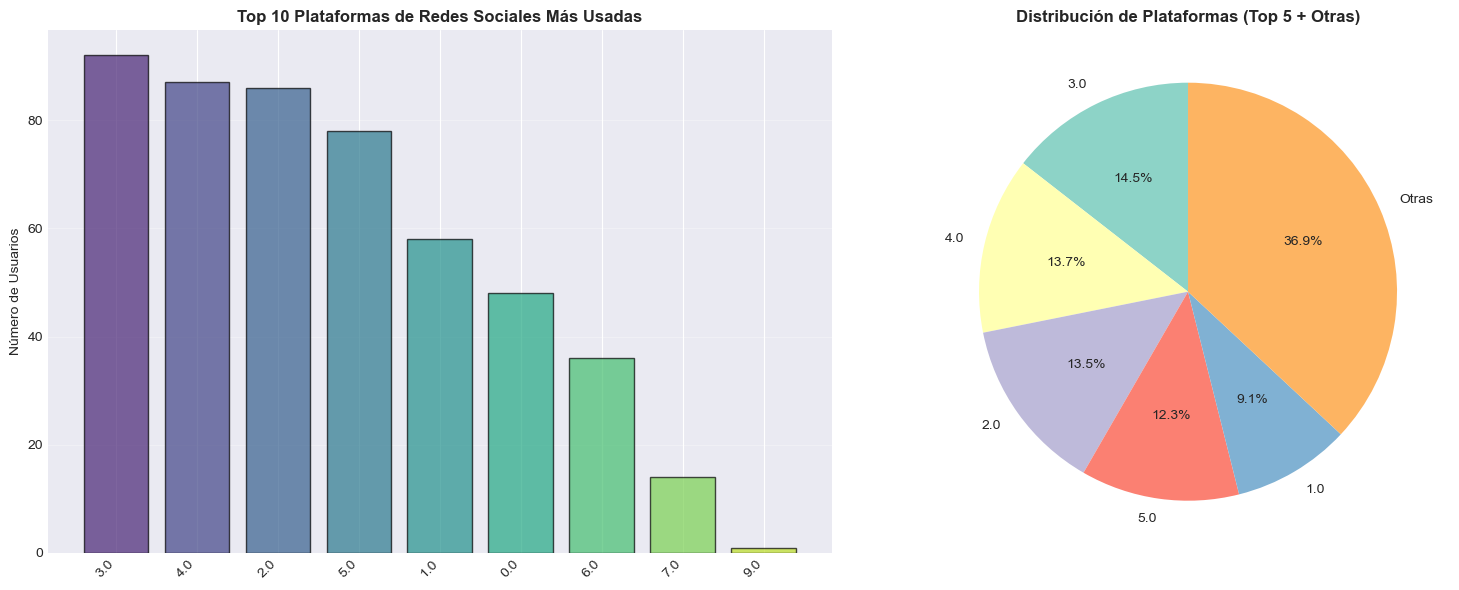

In [18]:
# Buscar columnas de plataformas
platform_cols = [col for col in df.columns if any(word in col.lower() 
                 for word in ['platform', 'app', 'social', 'media'])]

if platform_cols:
    platform_col = platform_cols[0]
    
    print(f"📱 Análisis de {platform_col}:")
    platform_counts = df[platform_col].value_counts()
    print(f"\n   • Plataformas únicas: {df[platform_col].nunique()}")
    print(f"\nTop 5 plataformas:")
    for i, (platform, count) in enumerate(platform_counts.head(5).items(), 1):
        pct = count / len(df) * 100
        print(f"   {i}. {platform}: {count} usuarios ({pct:.1f}%)")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Barplot
    top_platforms = platform_counts.head(10)
    axes[0].bar(range(len(top_platforms)), top_platforms.values, 
               color=sns.color_palette('viridis', len(top_platforms)),
               edgecolor='black', alpha=0.7)
    axes[0].set_xticks(range(len(top_platforms)))
    axes[0].set_xticklabels(top_platforms.index, rotation=45, ha='right')
    axes[0].set_ylabel('Número de Usuarios')
    axes[0].set_title('Top 10 Plataformas de Redes Sociales Más Usadas', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart
    top5 = platform_counts.head(5)
    others = platform_counts[5:].sum()
    pie_data = list(top5.values) + [others]
    pie_labels = list(top5.index) + ['Otras']
    
    colors = sns.color_palette('Set3', len(pie_data))
    axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
               colors=colors, startangle=90)
    axes[1].set_title('Distribución de Plataformas (Top 5 + Otras)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No se encontró columna de plataformas")

### 5.4. Indicadores de Salud Mental

🧠 Indicadores de Salud Mental encontrados:
   1. Sleep_Quality(1-10)
   2. Stress_Level(1-10)


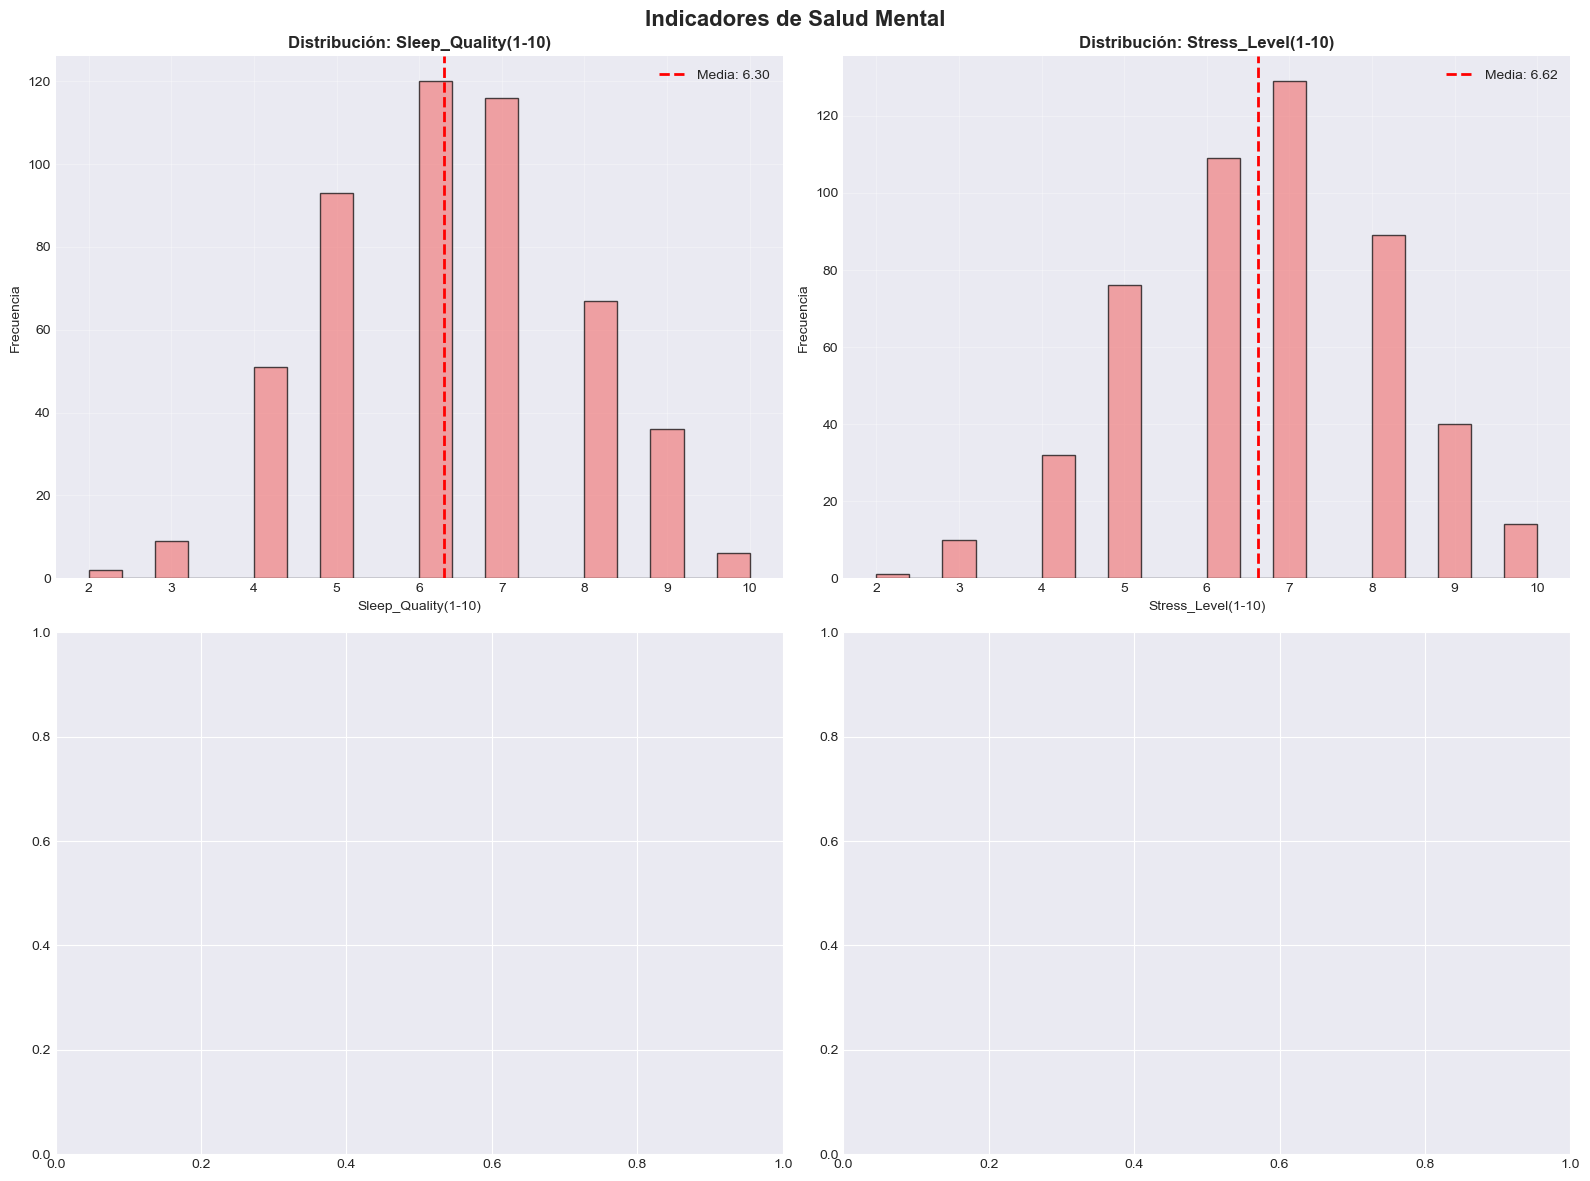

In [19]:
# Buscar columnas relacionadas con salud mental
mental_cols = [col for col in df.columns if any(word in col.lower() 
               for word in ['anxiety', 'depression', 'stress', 'mental', 'mood', 
                          'wellbeing', 'health', 'sleep', 'productivity'])]

if mental_cols:
    print("🧠 Indicadores de Salud Mental encontrados:")
    for i, col in enumerate(mental_cols, 1):
        print(f"   {i}. {col}")
    
    # Seleccionar primeros 4 indicadores para visualizar
    indicators_to_plot = mental_cols[:4]
    
    if len(indicators_to_plot) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()
        
        for idx, col in enumerate(indicators_to_plot):
            if df[col].dtype in ['int64', 'float64']:
                # Variable numérica
                axes[idx].hist(df[col].dropna(), bins=20, color='lightcoral',
                             edgecolor='black', alpha=0.7)
                axes[idx].axvline(df[col].mean(), color='red', linestyle='--',
                                linewidth=2, label=f'Media: {df[col].mean():.2f}')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frecuencia')
                axes[idx].legend()
            else:
                # Variable categórica
                value_counts = df[col].value_counts().head(10)
                axes[idx].bar(range(len(value_counts)), value_counts.values,
                            color=sns.color_palette('Pastel1', len(value_counts)),
                            edgecolor='black')
                axes[idx].set_xticks(range(len(value_counts)))
                axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
                axes[idx].set_ylabel('Frecuencia')
            
            axes[idx].set_title(f'Distribución: {col}', fontweight='bold')
            axes[idx].grid(alpha=0.3)
        
        plt.suptitle('Indicadores de Salud Mental', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("ℹ️  No se encontraron columnas de salud mental")

## 🔗 6. Análisis Bivariado: Relaciones Entre Variables

### 6.1. Correlación General Entre Variables Numéricas

📊 Análisis de correlación para 7 variables numéricas


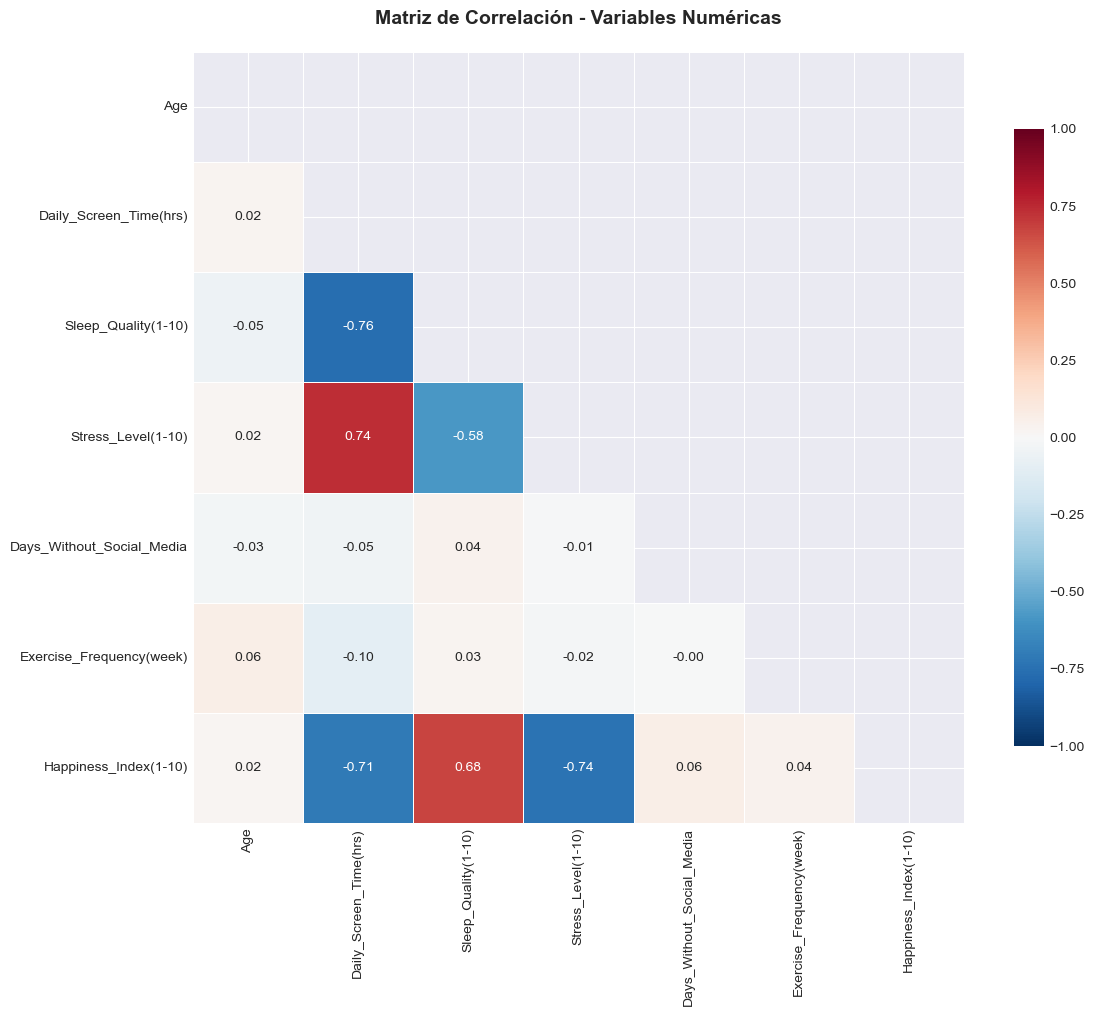

In [20]:
# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    print(f"📊 Análisis de correlación para {len(numeric_cols)} variables numéricas")
    
    # Calcular matriz de correlación
    corr_matrix = df[numeric_cols].corr()
    
    # Visualización con heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
               cmap='RdBu_r', center=0, vmin=-1, vmax=1,
               square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación - Variables Numéricas', 
             fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Pocas variables numéricas para análisis de correlación")

### 6.2. Tiempo de Uso vs Indicadores de Salud Mental

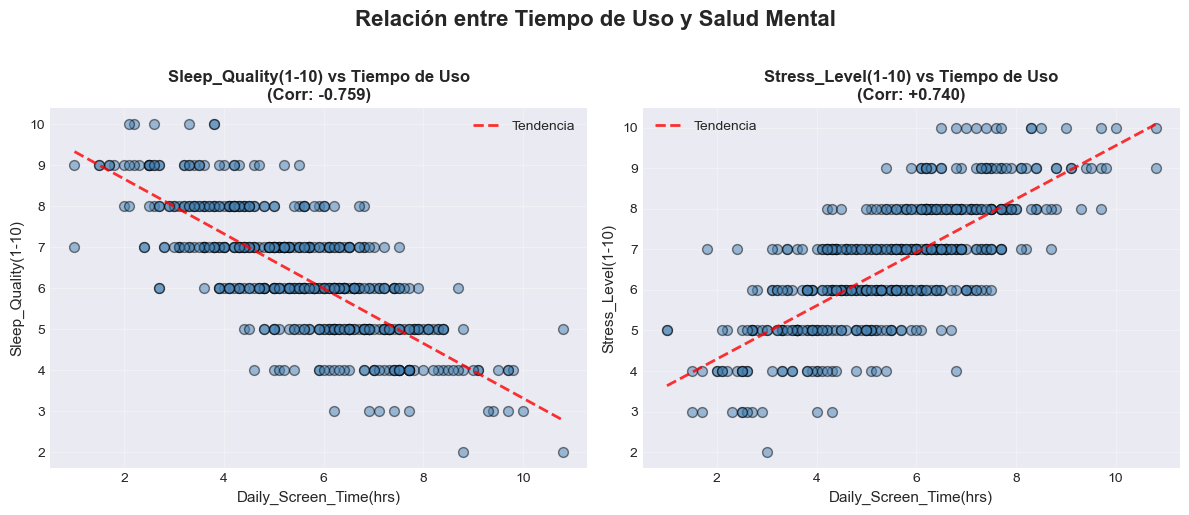

In [21]:
# Analizar relación entre tiempo de uso y salud mental
if time_cols and mental_cols:
    time_col = time_cols[0]
    
    # Seleccionar hasta 3 indicadores de salud mental
    mental_to_plot = [col for col in mental_cols if df[col].dtype in ['int64', 'float64']][:3]
    
    if mental_to_plot:
        fig, axes = plt.subplots(1, len(mental_to_plot), figsize=(6*len(mental_to_plot), 5))
        
        if len(mental_to_plot) == 1:
            axes = [axes]
        
        for idx, mental_col in enumerate(mental_to_plot):
            axes[idx].scatter(df[time_col], df[mental_col], 
                            alpha=0.5, c='steelblue', edgecolors='black', s=50)
            
            # Línea de tendencia
            z = np.polyfit(df[time_col].dropna(), 
                          df.loc[df[time_col].notna(), mental_col].dropna(), 1)
            p = np.poly1d(z)
            x_trend = np.linspace(df[time_col].min(), df[time_col].max(), 100)
            axes[idx].plot(x_trend, p(x_trend), "r--", linewidth=2, 
                          alpha=0.8, label='Tendencia')
            
            # Calcular correlación
            corr = df[[time_col, mental_col]].corr().iloc[0, 1]
            
            axes[idx].set_xlabel(f'{time_col}', fontsize=11)
            axes[idx].set_ylabel(f'{mental_col}', fontsize=11)
            axes[idx].set_title(f'{mental_col} vs Tiempo de Uso\n(Corr: {corr:+.3f})',
                              fontweight='bold')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
        
        plt.suptitle('Relación entre Tiempo de Uso y Salud Mental',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("ℹ️  No se pueden realizar comparaciones (faltan columnas)")

### 6.3. Plataforma vs Indicadores de Salud Mental

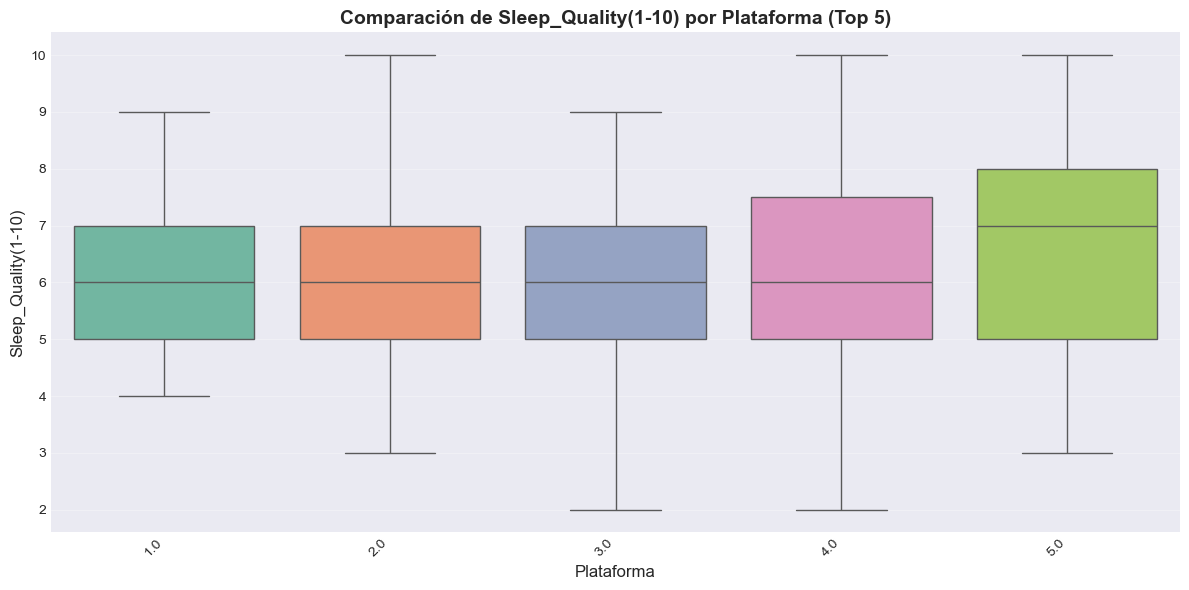


📊 Estadísticas de Sleep_Quality(1-10) por plataforma:
                           count  mean   std  min  25%  50%  75%   max
Days_Without_Social_Media                                             
1.0                         58.0  6.26  1.31  4.0  5.0  6.0  7.0   9.0
2.0                         86.0  6.06  1.52  3.0  5.0  6.0  7.0  10.0
3.0                         92.0  6.25  1.46  2.0  5.0  6.0  7.0   9.0
4.0                         87.0  6.49  1.54  2.0  5.0  6.0  7.5  10.0
5.0                         78.0  6.49  1.67  3.0  5.0  7.0  8.0  10.0


In [22]:
# Analizar si diferentes plataformas tienen diferentes impactos
if platform_cols and mental_cols:
    platform_col = platform_cols[0]
    mental_numeric = [col for col in mental_cols if df[col].dtype in ['int64', 'float64']]
    
    if mental_numeric:
        mental_col = mental_numeric[0]
        
        # Tomar solo top 5 plataformas para claridad
        top_platforms = df[platform_col].value_counts().head(5).index
        df_filtered = df[df[platform_col].isin(top_platforms)]
        
        plt.figure(figsize=(12, 6))
        
        # Boxplot
        sns.boxplot(data=df_filtered, x=platform_col, y=mental_col,
                   palette='Set2')
        
        plt.xlabel('Plataforma', fontsize=12)
        plt.ylabel(mental_col, fontsize=12)
        plt.title(f'Comparación de {mental_col} por Plataforma (Top 5)',
                 fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Estadísticas por plataforma
        print(f"\n📊 Estadísticas de {mental_col} por plataforma:")
        print(df_filtered.groupby(platform_col)[mental_col].describe().round(2))
else:
    print("ℹ️  No se pueden realizar comparaciones por plataforma")

### 6.4. Análisis por Grupos de Edad

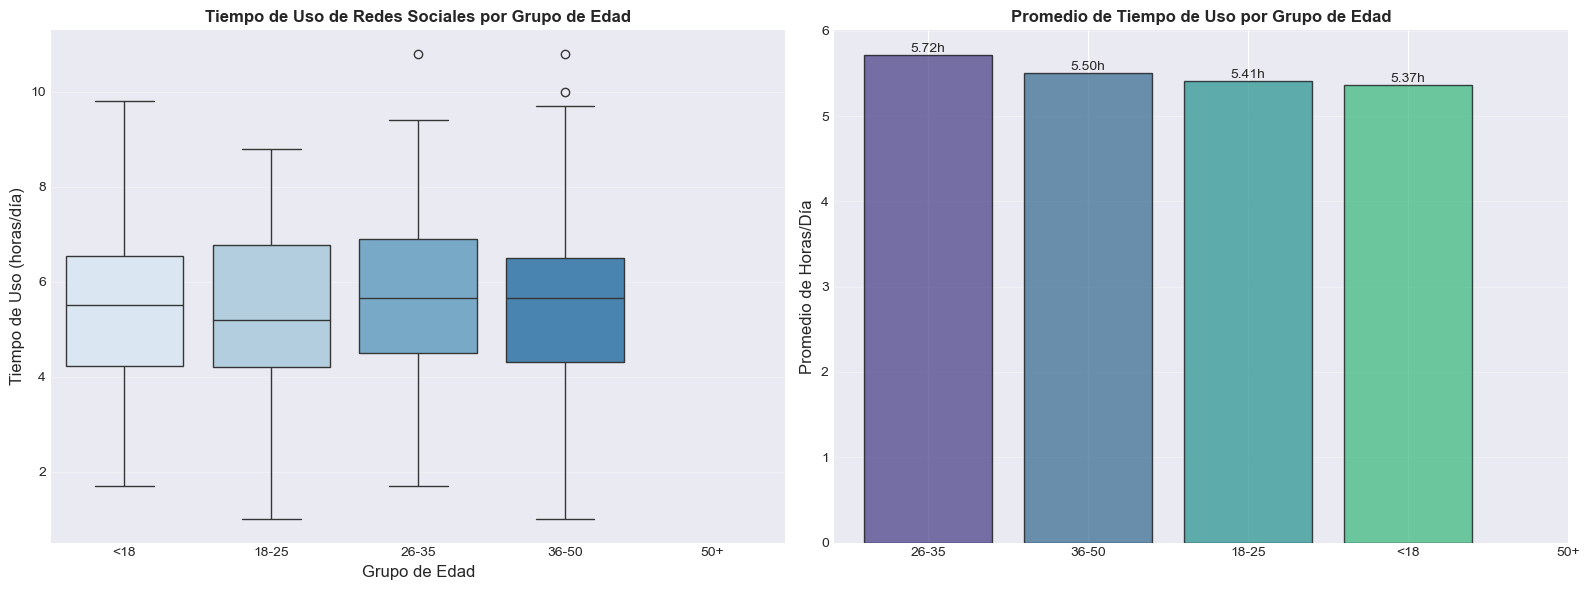


📊 Estadísticas de uso por grupo de edad:
           count  mean   std  min   25%   50%   75%   max
age_group                                                
<18         50.0  5.37  1.87  1.7  4.22  5.50  6.55   9.8
18-25       90.0  5.41  1.84  1.0  4.20  5.20  6.78   8.8
26-35      134.0  5.72  1.67  1.7  4.50  5.65  6.90  10.8
36-50      226.0  5.50  1.70  1.0  4.30  5.65  6.50  10.8
50+          0.0   NaN   NaN  NaN   NaN   NaN   NaN   NaN


In [23]:
# Crear grupos de edad y analizar patrones
if age_cols and time_cols:
    age_col = age_cols[0]
    time_col = time_cols[0]
    
    # Crear categorías de edad
    df['age_group'] = pd.cut(df[age_col], 
                             bins=[0, 18, 25, 35, 50, 100],
                             labels=['<18', '18-25', '26-35', '36-50', '50+'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Boxplot de tiempo de uso por edad
    sns.boxplot(data=df, x='age_group', y=time_col, ax=axes[0], palette='Blues')
    axes[0].set_xlabel('Grupo de Edad', fontsize=12)
    axes[0].set_ylabel('Tiempo de Uso (horas/día)', fontsize=12)
    axes[0].set_title('Tiempo de Uso de Redes Sociales por Grupo de Edad',
                     fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Barplot de promedio por grupo
    age_means = df.groupby('age_group')[time_col].mean().sort_values(ascending=False)
    bars = axes[1].bar(range(len(age_means)), age_means.values,
                      color=sns.color_palette('viridis', len(age_means)),
                      edgecolor='black', alpha=0.7)
    axes[1].set_xticks(range(len(age_means)))
    axes[1].set_xticklabels(age_means.index)
    axes[1].set_ylabel('Promedio de Horas/Día', fontsize=12)
    axes[1].set_title('Promedio de Tiempo de Uso por Grupo de Edad',
                     fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, value in zip(bars, age_means.values):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.2f}h', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Estadísticas de uso por grupo de edad:")
    print(df.groupby('age_group')[time_col].describe().round(2))
else:
    print("ℹ️  No se puede realizar análisis por edad (columnas faltantes)")

## 🎨 7. Análisis Multivariado Avanzado

📊 Generando pairplot para 5 variables clave...
Variables seleccionadas: ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)', 'Stress_Level(1-10)', 'Days_Without_Social_Media']


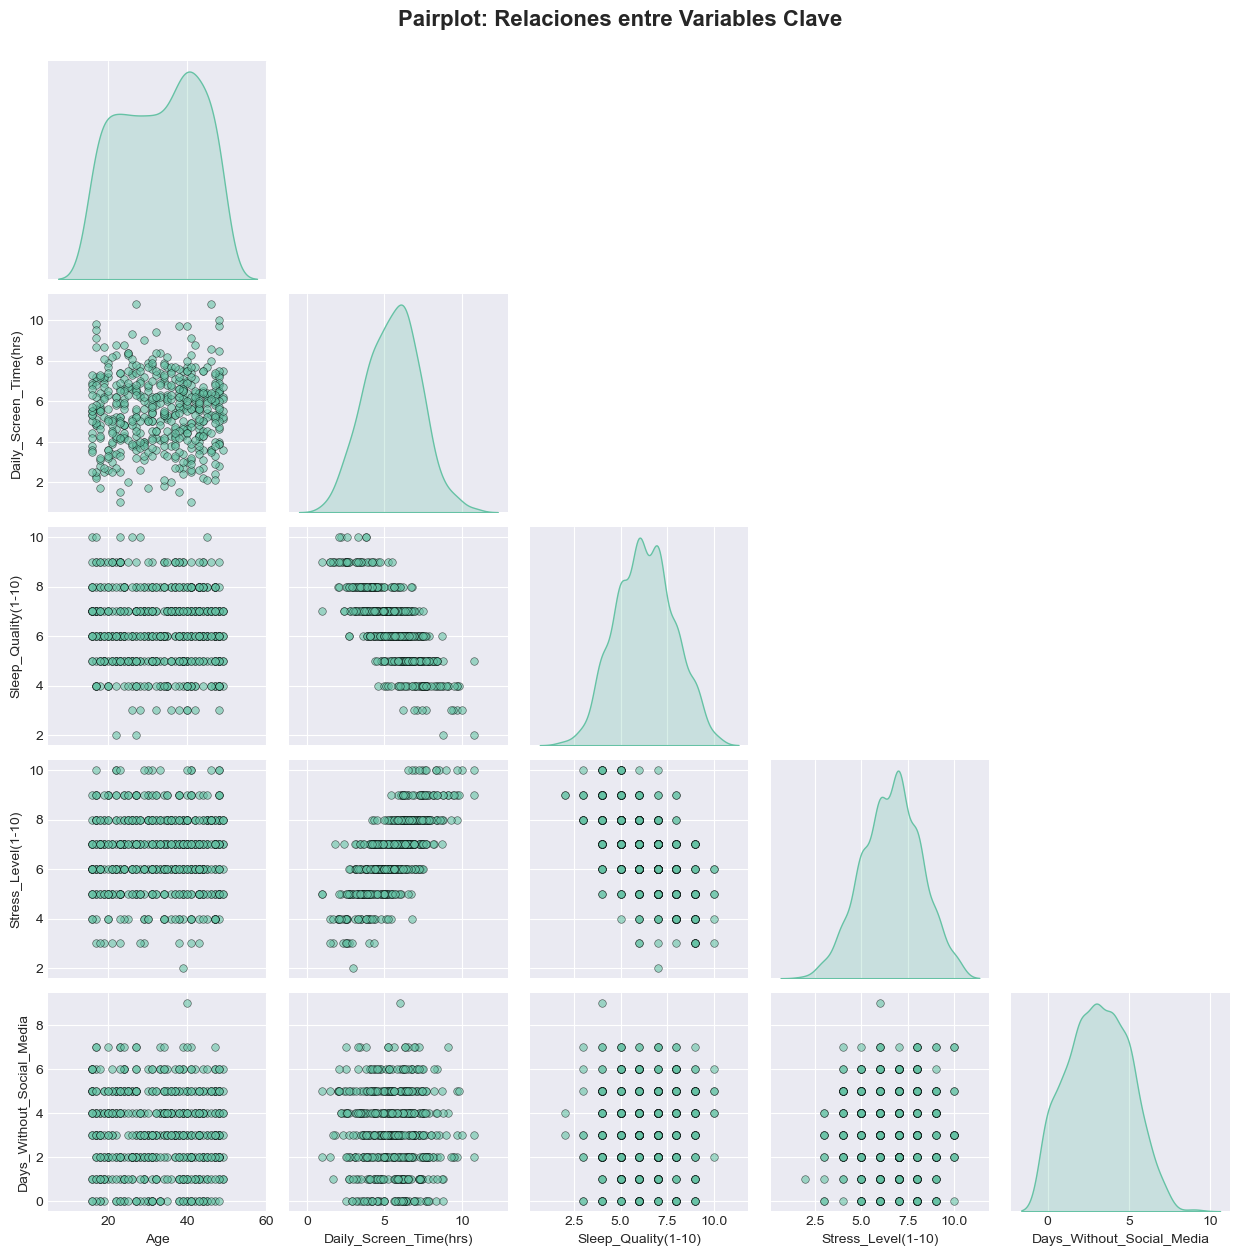

In [24]:
# Pairplot de variables clave (si hay suficientes numéricas)
if len(numeric_cols) >= 3:
    # Seleccionar hasta 5 variables más importantes
    key_vars = numeric_cols[:5]
    
    print(f"📊 Generando pairplot para {len(key_vars)} variables clave...")
    print("Variables seleccionadas:", key_vars)
    
    # Crear pairplot
    sns.pairplot(df[key_vars].dropna(), 
                diag_kind='kde', 
                plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'black'},
                corner=True)
    plt.suptitle('Pairplot: Relaciones entre Variables Clave', 
                fontsize=16, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  Pocas variables numéricas para pairplot")

## 💡 8. Conclusiones e Insights Principales

In [25]:
print("="*70)
print("📋 RESUMEN EJECUTIVO DEL ANÁLISIS")
print("="*70)

print(f"\n📊 DATASET:")
print(f"   • Total de registros: {len(df):,}")
print(f"   • Variables analizadas: {df.shape[1]}")
print(f"   • Variables numéricas: {len(numeric_cols)}")
print(f"   • Completitud: {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%")

if age_cols:
    age_col = age_cols[0]
    print(f"\n👥 DEMOGRAFÍA:")
    print(f"   • Edad promedio: {df[age_col].mean():.1f} años")
    print(f"   • Rango de edad: {df[age_col].min():.0f} - {df[age_col].max():.0f} años")

if time_cols:
    time_col = time_cols[0]
    print(f"\n⏱️ USO DE REDES SOCIALES:")
    print(f"   • Tiempo promedio diario: {df[time_col].mean():.2f} horas")
    print(f"   • Desviación estándar: {df[time_col].std():.2f} horas")
    print(f"   • Usuarios con uso >4h/día: {(df[time_col] > 4).sum()} ({(df[time_col] > 4).sum()/len(df)*100:.1f}%)")

if platform_cols:
    platform_col = platform_cols[0]
    top_platform = df[platform_col].value_counts().index[0]
    print(f"\n📱 PLATAFORMAS:")
    print(f"   • Plataformas únicas: {df[platform_col].nunique()}")
    print(f"   • Plataforma más popular: {top_platform}")

if mental_cols and time_cols:
    mental_numeric = [col for col in mental_cols if df[col].dtype in ['int64', 'float64']]
    if mental_numeric:
        mental_col = mental_numeric[0]
        corr = df[[time_col, mental_col]].corr().iloc[0, 1]
        print(f"\n🧠 SALUD MENTAL:")
        print(f"   • Correlación tiempo-salud mental: {corr:+.3f}")
        if abs(corr) > 0.3:
            direction = "positiva" if corr > 0 else "negativa"
            print(f"   • ⚠️  Relación {direction} moderada detectada")

print(f"\n🎯 INSIGHTS CLAVE:")
print(f"   1. Análisis exploratorio completado exitosamente")
print(f"   2. Patrones identificados en uso de redes sociales")
print(f"   3. Relaciones entre variables documentadas")
print(f"   4. Base sólida para análisis predictivo posterior")

print("\n" + "="*70)

📋 RESUMEN EJECUTIVO DEL ANÁLISIS

📊 DATASET:
   • Total de registros: 500
   • Variables analizadas: 11
   • Variables numéricas: 7
   • Completitud: 100.0%

👥 DEMOGRAFÍA:
   • Edad promedio: 33.0 años
   • Rango de edad: 16 - 49 años

⏱️ USO DE REDES SOCIALES:
   • Tiempo promedio diario: 5.53 horas
   • Desviación estándar: 1.73 horas
   • Usuarios con uso >4h/día: 397 (79.4%)

📱 PLATAFORMAS:
   • Plataformas únicas: 9
   • Plataforma más popular: 3.0

🧠 SALUD MENTAL:
   • Correlación tiempo-salud mental: -0.759
   • ⚠️  Relación negativa moderada detectada

🎯 INSIGHTS CLAVE:
   1. Análisis exploratorio completado exitosamente
   2. Patrones identificados en uso de redes sociales
   3. Relaciones entre variables documentadas
   4. Base sólida para análisis predictivo posterior



## 🤖 9. BONUS: Reporte Automático con ydata-profiling

In [26]:
# Instalar ydata-profiling si no está instalado
# !pip install ydata-profiling

try:
    from ydata_profiling import ProfileReport
    
    print("🤖 Generando reporte automático completo...")
    print("⏳ Esto puede tomar varios minutos...")
    
    # Crear perfil del dataset
    profile = ProfileReport(df, 
                           title="Social Media & Mental Health - EDA Report",
                           explorative=True,
                           minimal=False)
    
    # Guardar reporte HTML
    output_file = "social_media_mental_health_eda_report.html"
    profile.to_file(output_file)
    
    import os
    out_path = os.path.abspath(output_file)
    print(f"\n✅ Reporte generado exitosamente!")
    print(f"📂 Ubicación: {out_path}")
    print(f"🌐 Abre el archivo HTML en tu navegador para ver el reporte completo")
    
    # Mostrar reporte en notebook (si estás en Jupyter)
    profile
    
except ImportError:
    print("⚠️  ydata-profiling no está instalado.")
    print("Para instalar: pip install ydata-profiling")
except Exception as e:
    print(f"❌ Error al generar reporte: {e}")

🤖 Generando reporte automático completo...
⏳ Esto puede tomar varios minutos...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 209.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Reporte generado exitosamente!
📂 Ubicación: /Users/milagroscancela/Desktop/portfolio-ia/portfolio-ia/docs/portfolio/assets/social-media/social_media_mental_health_eda_report.html
🌐 Abre el archivo HTML en tu navegador para ver el reporte completo


---

## 📚 Referencias y Recursos

### Dataset
- **Kaggle**: [Social Media and Mental Health Balance](https://www.kaggle.com/datasets/ayeshaimran123/social-media-and-mental-health-balance)

### Documentación Técnica
- **Pandas**: [pandas.pydata.org](https://pandas.pydata.org/docs/)
- **Matplotlib**: [matplotlib.org](https://matplotlib.org/stable/contents.html)
- **Seaborn**: [seaborn.pydata.org](https://seaborn.pydata.org/)
- **ydata-profiling**: [docs.profiling.ydata.ai](https://docs.profiling.ydata.ai/)

### Contexto Académico
- **Curso**: Análisis Exploratorio de Datos (EDA) - UT1
- **Institución**: Universidad Católica del Uruguay
- **Programa**: Ingeniería de Datos
- **Profesor**: Juan F. Kurucz

---

> 📅 **Fecha:** Noviembre 2025  
> 👤 **Autora:** Milagros Cancela  
> 🎓 **Universidad Católica del Uruguay** - Ingeniería de Datos  
> 📧 **Contacto:** milagros.cancela@correo.ucu.edu.uy

---